Dataset Shape: (150, 4)
Target Shape: (150,)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

Best Parameters:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Best Cross Validation Accuracy:
0.9833

Test Accuracy:
0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



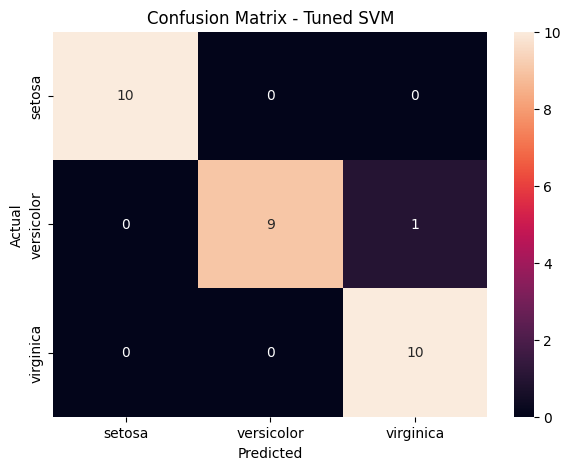


Top 5 Grid Search Results:
    param_C param_kernel param_gamma  mean_test_score  rank_test_score
15      1.0          rbf         0.1         0.983333                1
0       0.1       linear       scale         0.975000                2
6       0.1       linear         0.1         0.975000                2
2       0.1       linear        auto         0.975000                2
10      1.0       linear        auto         0.975000                2

5-Fold Cross Validation Scores:
[0.95833333 1.         0.91666667 1.         0.875     ]

Mean Cross Validation Accuracy:
0.95

Standard Deviation:
0.0486


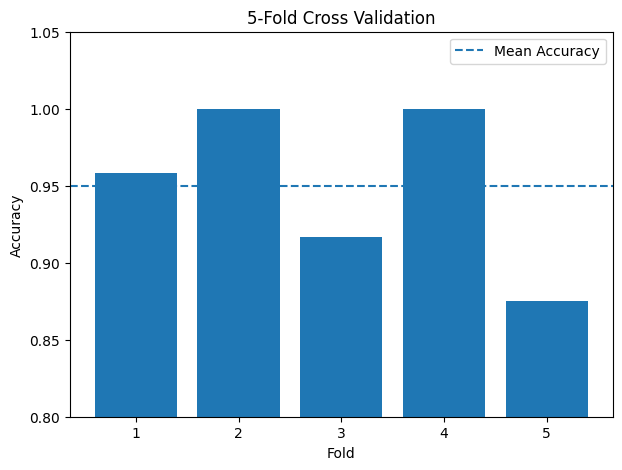

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)
print("Features:", iris.feature_names)
print("Classes:", iris.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC()

parameters = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto", 0.01, 0.1]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=parameters,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(grid.best_score_, 4))

best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("\nTest Accuracy:")
print(round(accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=iris.target_names
    )
)

matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned SVM")
plt.show()

results = pd.DataFrame(grid.cv_results_)

top_results = results[
    [
        "param_C",
        "param_kernel",
        "param_gamma",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

print("\nTop 5 Grid Search Results:")
print(top_results.head())

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_model = SVC(
    C=grid.best_params_["C"],
    kernel=grid.best_params_["kernel"],
    gamma=grid.best_params_["gamma"]
)

scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=kf,
    scoring="accuracy"
)

print("\n5-Fold Cross Validation Scores:")
print(scores)

print("\nMean Cross Validation Accuracy:")
print(round(np.mean(scores), 4))

print("\nStandard Deviation:")
print(round(np.std(scores), 4))

plt.figure(figsize=(7, 5))

plt.bar(
    range(1, 6),
    scores
)

plt.axhline(
    np.mean(scores),
    linestyle="--",
    label="Mean Accuracy"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation")
plt.xticks(range(1, 6))
plt.ylim(0.8, 1.05)
plt.legend()
plt.show()